# Pandas 실습 2

### 1. 데이터 준비
- 서울시 공공자전거(따릉이) 대여 데이터

In [9]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import platform

if platform.system() == 'Windows':
    matplotlib.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
else:
    matplotlib.rc('font', family='DejaVu Sans')

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print('NumPy 버전:', np.__version__)
print('환경 설정 완료')

NumPy 버전: 2.3.5
환경 설정 완료


In [10]:
import pandas as pd

In [11]:
# 데이터 로드
df1 = pd.read_csv('data/서울특별시 공공자전거 일별 대여건수_25.7-12.csv')
df1.head()

,대여일자,대여건수
0,2025-07-01,132914
1,2025-07-02,151653
2,2025-07-03,151092
3,2025-07-04,151367
4,2025-07-05,118354


In [94]:
# 데이터 로드
df2 = pd.read_excel('data/대여소별 대여내역(2017년).xlsx')
df2.head()

,대여소 그룹,대여소 명,대여 일자 / 월,대여 건수
0,그룹명 없음,대여소명 없음,2017-01-01,0
1,광진구,500. 어린이대공원역 3번출구 앞,2017-01-01,20
2,광진구,501. 광진구의회 앞,2017-01-01,10
3,광진구,502. 뚝섬유원지역 1번출구 앞,2017-01-01,9
4,광진구,503. 더샵스타시티 C동 앞,2017-01-01,9


In [95]:
# df1의 일자별 대여건수 top10
df1.shape
df1['대여일자'].value_counts()
df1['대여일자'].dtypes

dtype('<M8[ns]')

In [14]:
# '대여일자' 데이터 타입 변환, to_datetime()
df1['대여일자'] = pd.to_datetime(df1['대여일자'])
df1.dtypes
df1['Year'] = df1['대여일자'].dt.year
df1['Month'] = df1['대여일자'].dt.month
df1['Day'] = df1['대여일자'].dt.day
df1['Month'].value_counts()

Month
7     31
8     31
10    31
12    31
9     30
11    30
Name: count, dtype: int64

In [15]:
# df1의 2025년도 월별 대여건수 
df1_rentals = df1.groupby('Month')['Month'].sum()
df1_rentals
df1_rentals.index
#df1_rentals.values

Index([7, 8, 9, 10, 11, 12], dtype='int32', name='Month')

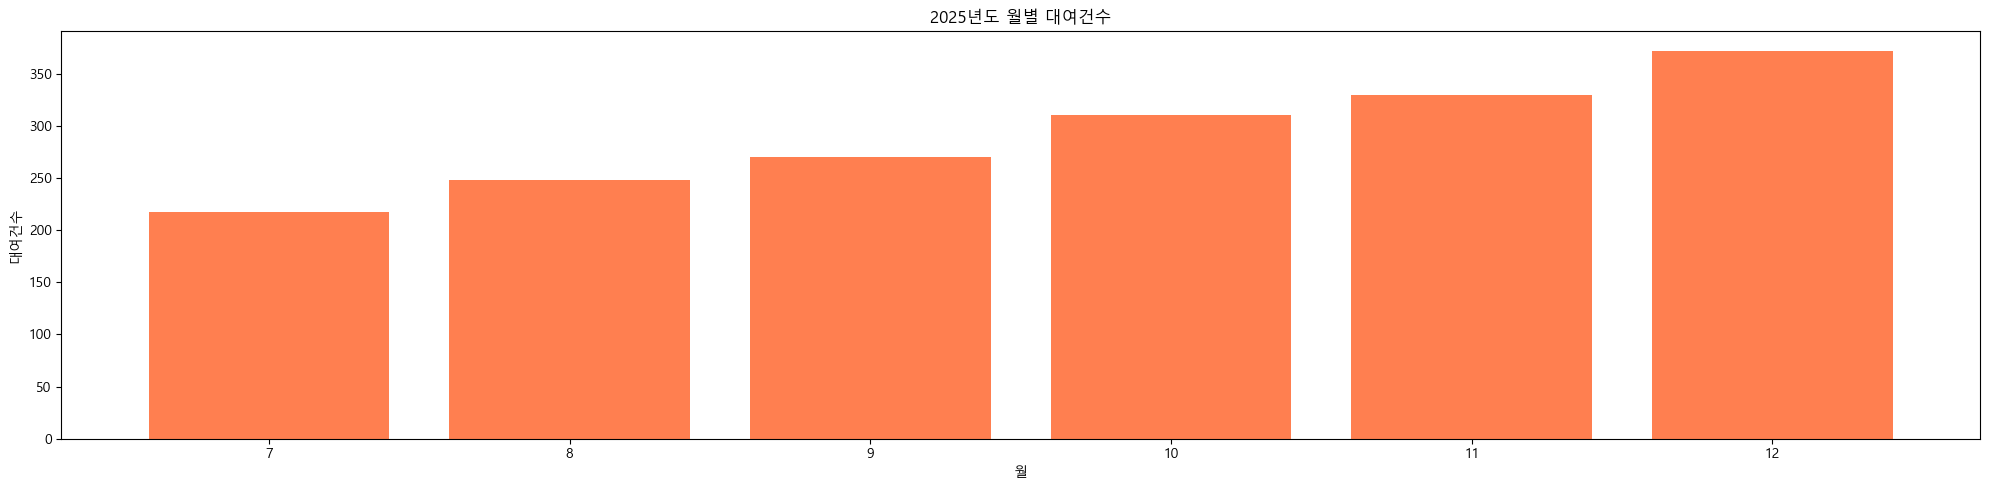

In [43]:
# 막대 그래프
plt.figure(figsize=(20, 5))
plt.bar(df1_rentals.index, df1_rentals.values, color='coral')
plt.title('2025년도 월별 대여건수')
plt.xlabel('월')
plt.ylabel('대여건수')
# plt.gca().invert_xaxis()
# plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

- 요일별 대여건수 그래프 시각화

In [20]:
df1.dtypes
df1['대여일자'].dt.day_name() # 영문 요일 조회

0        Tuesday
1      Wednesday
2       Thursday
3         Friday
4       Saturday
         ...    
179     Saturday
180       Sunday
181       Monday
182      Tuesday
183    Wednesday
Name: 대여일자, Length: 184, dtype: object

In [ ]:
# 0:월요일, 1:화요일...
# 'weekday' 컬럼을 생성하고 요일 정보를 저장
df1['weekday'] = df1['대여일자'].dt.weekday 
df1

In [28]:
# 요일을 매핑하는 딕셔너리 객체 생성
week_dict = {
    0: '월',
    1: '화',
    2: '수',
    3: '목',
    4: '금',
    5: '토',
    6: '일'
}
df1['weekday'] = df1['대여일자'].dt.weekday.map(week_dict)
df1.head(3)

,대여일자,대여건수,Year,Month,Day,weekday
0,2025-07-01,132914,2025,7,1,화
1,2025-07-02,151653,2025,7,2,수
2,2025-07-03,151092,2025,7,3,목


In [49]:
# 요일별 대여건수 그래프 생성
order = ['월','화','수','목','금','토','일']
df1['weekday'].value_counts() 
result = df1.groupby('weekday')['대여건수'].sum().reindex(order)
result

weekday
월    2860997
화    3125484
수    3052445
목    3120020
금    2871785
토    2322797
일    2294234
Name: 대여건수, dtype: int64

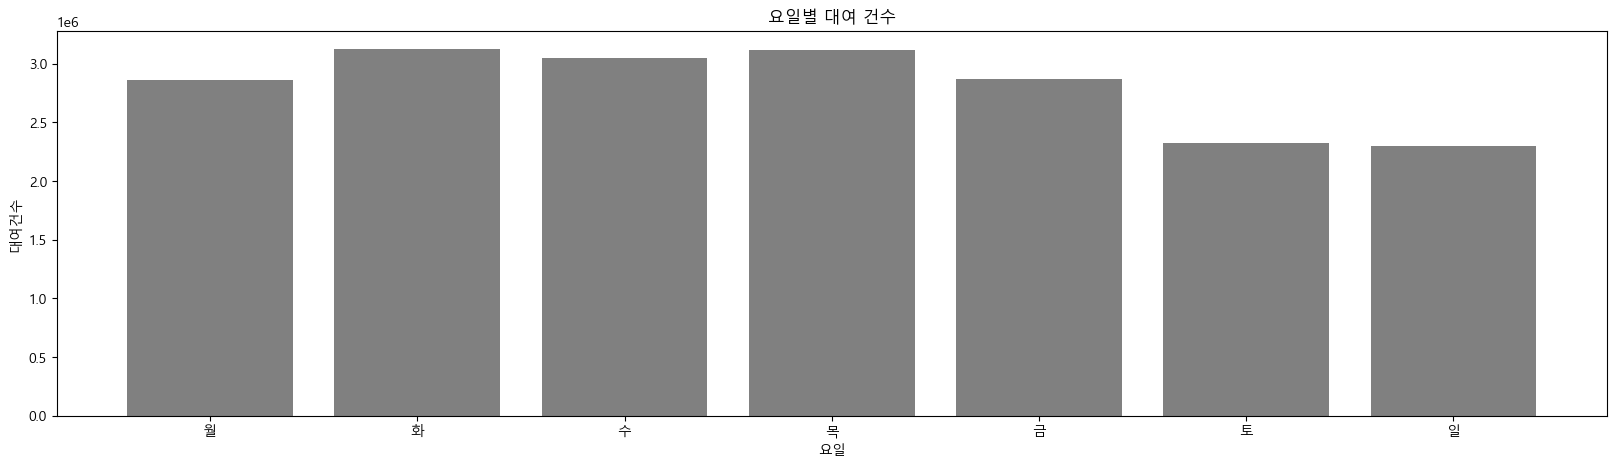

In [52]:
plt.figure(figsize=(20, 5))
plt.bar(result.index, result.values, color="gray")
plt.title('요일별 대여 건수')
plt.xlabel('요일')
plt.ylabel('대여건수')
plt.show()

In [ ]:
# df2의 대여소별 대여건수 top5
df2.head()
df2.shape
df2.info()

In [96]:
# df2 컬럼명 수정
df2.head()
df2.rename(columns={'대여소 그룹':'그룹'})
df2.columns = ['그룹','대여소','일자','건수']
df2

,그룹,대여소,일자,건수
0,그룹명 없음,대여소명 없음,2017-01-01,0
1,광진구,500. 어린이대공원역 3번출구 앞,2017-01-01,20
2,광진구,501. 광진구의회 앞,2017-01-01,10
3,광진구,502. 뚝섬유원지역 1번출구 앞,2017-01-01,9
4,광진구,503. 더샵스타시티 C동 앞,2017-01-01,9
...,...,...,...,...
245441,중랑구,1442. (구)신한은행 중랑교지점,2017-12-31,3
245442,중랑구,1445. 용마지구대,2017-12-31,1
245443,중랑구,1446. 중랑전화국 교차로,2017-12-31,3
245444,중랑구,1447. 면목역 3번출구,2017-12-31,1


In [71]:
# 대여소별 대여건수 Top5
df2['대여소'].value_counts()
station_top5 = df2.groupby('대여소')['건수'].sum().sort_values(ascending=False).head(10)
station_top5

대여소
207. 여의나루역 1번출구 앞       54488
113. 홍대입구역 2번출구 앞       42185
502. 뚝섬유원지역 1번출구 앞      38856
152. 마포구민체육센터 앞         25380
106. 합정역 7번출구 앞         22432
358. 성대입구 사거리           22146
247. 당산역 10번출구 앞        21495
540. 군자역 7번출구 베스트샵 앞    21211
419. 홈플러스 앞             21056
907. CJ 드림시티            20892
Name: 건수, dtype: int64

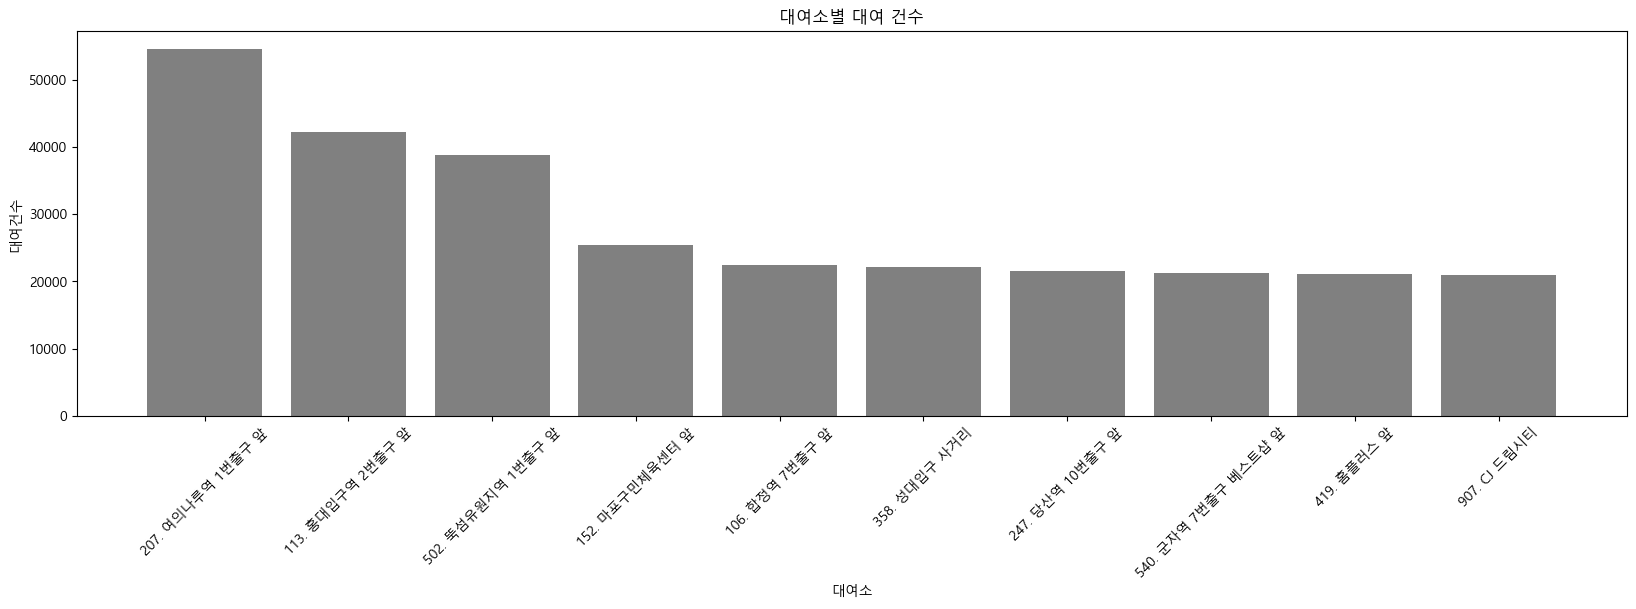

In [73]:
plt.figure(figsize=(20, 5))
plt.bar(station_top5.index, station_top5.values, color="gray")
plt.title('대여소별 대여 건수')
plt.xlabel('대여소')
plt.ylabel('대여건수')
plt.xticks(rotation=45)
plt.show()

- 그룹별 총 대여건수 Top10

In [ ]:
df2.head()
gu_top10 = df2.groupby('그룹')['건수'].sum().sort_values(ascending=False).head(10)
gu_top10

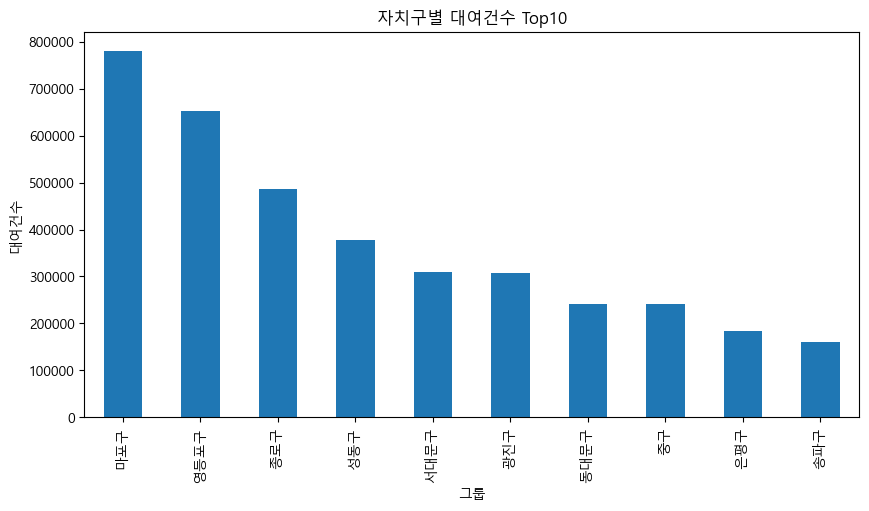

In [82]:
gu_top10.plot(
    kind='bar',
    figsize=(10, 5)
)
plt.title('자치구별 대여건수 Top10')
plt.ylabel('대여건수')
plt.show()

- 월별 전체 대여건수 

In [ ]:
df2.head()
df2.dtypes
df2['월'] = df2['일자'].dt.month
month_rent = df2.groupby('월')['건수'].sum()
month_rent

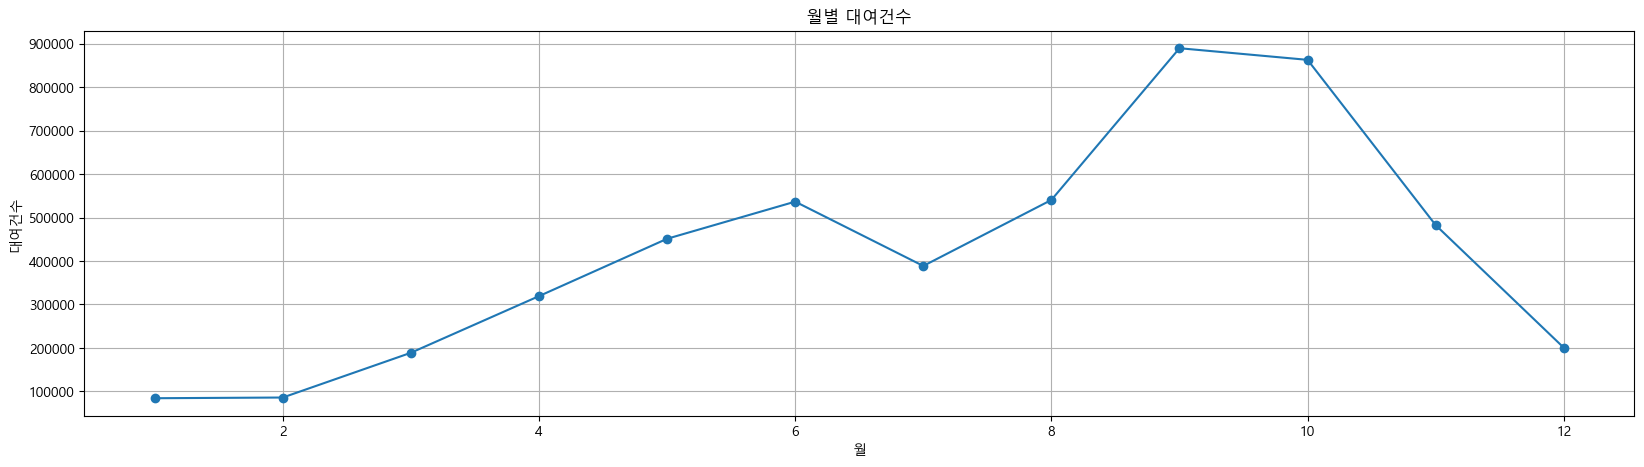

In [93]:
month_rent.plot(
    kind='line',
    marker='o',
    figsize=(20, 5)
)
plt.title('월별 대여건수')
plt.ylabel('대여건수')
plt.grid()
plt.show()

- 대여소별 평균 대여건수 Top15

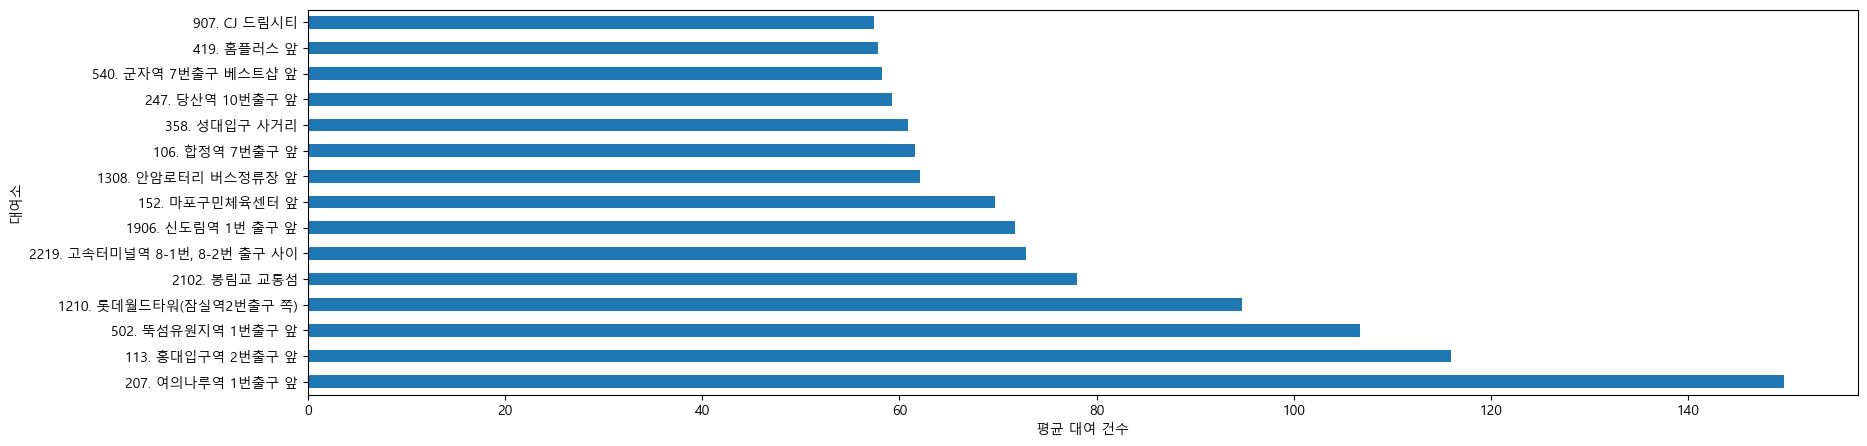

In [104]:
# df2.info()
group_mean = df2.groupby('대여소')['건수'].mean().sort_values(ascending=False).head(15)
group_mean

# 그래프
group_mean.plot(
    kind='barh',
    figsize=(20, 5)
)
plt.xlabel('평균 대여 건수')
plt.show()